# TP Aprendizaje Maquina

Esta notebook detalla la propuesta de investigación, las decisiones tomadas y los resultados obtenidos en el desarrollo de modelos para estimar la gravedad del impacto material de eventos climáticos utilizando el dataset **NOAA Storm Events**.

## 1. Propuesta de Investigación

### Objetivo
El propósito principal de esta es anticipar o predecir la gravedad del impacto material que un evento climatológico tendrá sobre el terreno. El impacto económico y social de los desastres naturales es sumamente severo y contar con herramientas predictivas capaces de estimar el nivel de daños permite una mejor asignación de recursos de emergencia, planificación de infraestructura y mitigación de riesgos.

### Definición del Target (`DAMAGE_CLASS`)
Para modelar la gravedad de los daños, se construyó la variable objetivo **`DAMAGE_CLASS`** a partir del total de daños reales (propiedades y cultivos ajustados a la inflación). Esta variable clasifica la gravedad en 5 categorías ordenadas:
- **Clase 0**: Sin daño (= 0 USD)
- **Clase 1**: Daño Menor (0 - 10K USD]
- **Clase 2**: Daño Moderado (10K - 100K USD]
- **Clase 3**: Daño Severo (100K - 1M USD]
- **Clase 4**: Daño Catastrófico (> 1M USD]

### Analisis de datos
Para conocer los datos que tenemos a disposicion, realizamos un EDA donde principalemnte detectamos features que no aportaban mucha informacion y gran cantidad de valores faltantes. Agregamos algunas features que nos indican ausencia, otras que nos dan informacion geofragica y temporal adicional y un ajuste inflacionario. Este proceso se puede observar en detalle en la notebook `1_storm_events_final`.

### Preprocesameinto, Codificacion y Split
Partiendo del dataset limpio obtenido anteriormente, se realizo el escalamiento y codificacion en funcion del tipo de modelo a utilizar asi como el split de los datos en Train, Validate y Test de forma temporal. Este proceso se puede observar en detalle en la notebook `2_storm_events_split_final`.

### Desafíos del Dataset
El dataset presenta un desbalance de clases sumamente severo. Los eventos sin daño o con daños mínimos representan la gran mayoría del dataset, mientras que los eventos de alto impacto (Clases 3 y 4) son extremadamente raros pero representan la mayor parte de las pérdidas reales.


## 2. Elección del Algoritmo
Para resolver este problema, se opto por probar distintos metodos y seleccionar aquel que demuestre mejores resultados.

El entrenamiento se encuentra en 
- `3_storm_events_ml_models`
- `catboost_class`
- ............

## 3. Resultados Obtendios

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix

In [2]:
#Cargamos datos de Test
X_TEST_PATH = "processed_datasets/X_test_catboost.parquet"
Y_TEST_PATH = "processed_datasets/y_test.csv"

X_test = pd.read_parquet(X_TEST_PATH, engine="fastparquet")
y_test = pd.read_csv(Y_TEST_PATH).squeeze()

print(f"Dimensiones de X_test: {X_test.shape}")
print(f"Dimensiones de y_test: {y_test.shape}")

Dimensiones de X_test: (115998, 32)
Dimensiones de y_test: (115998,)


### 3.1 Modelo Catboost

              precision    recall  f1-score   support

           0       0.94      0.86      0.90     86950
           1       0.62      0.74      0.67     17859
           2       0.28      0.32      0.30      7736
           3       0.20      0.32      0.25      2274
           4       0.21      0.43      0.28      1179

    accuracy                           0.79    115998
   macro avg       0.45      0.53      0.48    115998
weighted avg       0.83      0.79      0.81    115998



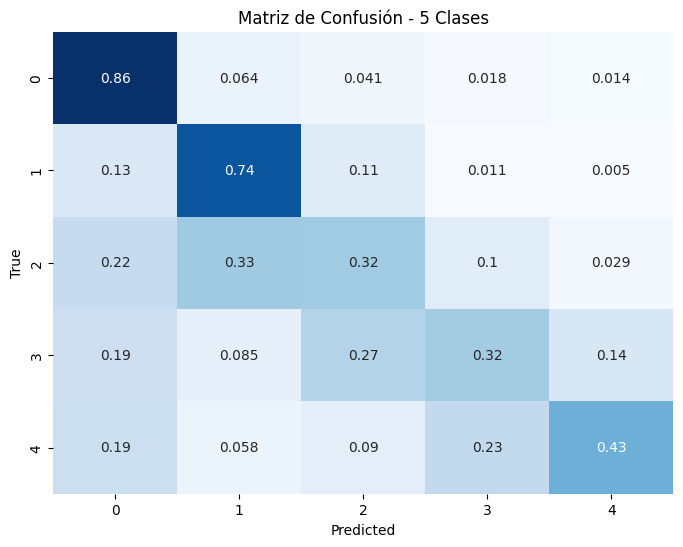

In [16]:
PATH_CATBOOST_ALL = 'models/catboost_all.cbm'

model_all = CatBoostClassifier().load_model(PATH_CATBOOST_ALL)

y_pred_all = model_all.predict(X_test).flatten().astype(int)

print(classification_report(y_test, y_pred_all))
cm_all = confusion_matrix(y_test, y_pred_all,normalize='true')

plt.figure(figsize=(8, 6))
sns.heatmap(cm_all, annot=True, cbar=False,cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Matriz de Confusión - 5 Clases')
plt.show()

## 4. Discusión de resultados obtenidos

A partir de las métricas de los modelos, observamos que todos fallan en clasificar correctamente las clases de mayor gravedad, siendo una posible explicacion, el desbalance de clases.

Para tratar este inconveniente se propone agrupar las categorias 2, 3 y 4 en una sola, redefininedo entonces el problema como:

- **Clase 0**: Sin daño (= 0 USD)
- **Clase 1**: Daño Menor (0 - 10K USD]
- **Clase 2**: Daño Alto (> 10K USD]

En base a los modelos que mejor funcionaron en la etapa anterior, procederemos a entrenarlos pero ahora con este agrupamiento. El proceso se puede observar en:
- `0_1_2`
- .....................

## 5. Resultados obtenidos en modelos para clasificacion en 3 clases

### 5.1 CatBoost

              precision    recall  f1-score   support

           0       0.94      0.89      0.91     86950
           1       0.62      0.76      0.68     17859
           2       0.47      0.49      0.48     11189

    accuracy                           0.83    115998
   macro avg       0.68      0.71      0.69    115998
weighted avg       0.85      0.83      0.84    115998



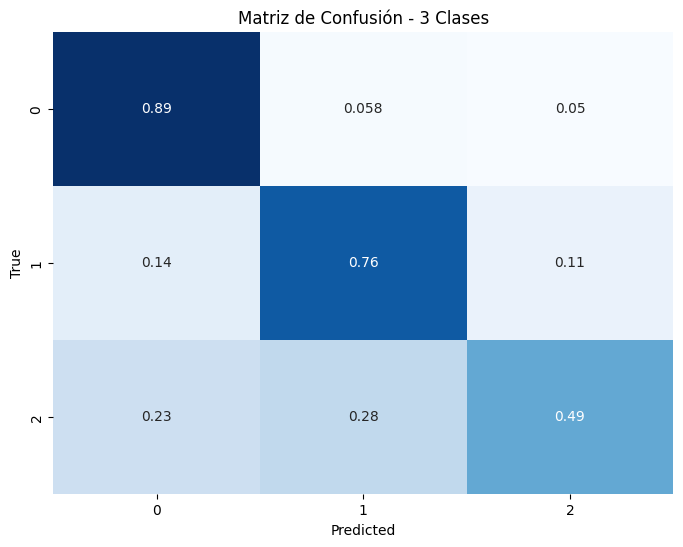

In [17]:
PATH_012 = 'models/catboost_012.cbm'

model_012 = CatBoostClassifier().load_model(PATH_012)

y_pred_012 = model_012.predict(X_test).flatten().astype(int)

print(classification_report(np.clip(y_test, 0, 2), y_pred_012))
cm_012 = confusion_matrix(np.clip(y_test, 0, 2), y_pred_012, normalize='true')
plt.figure(figsize=(8, 6))
sns.heatmap(cm_012, annot=True, cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Matriz de Confusión - 3 Clases')
plt.show()

## 6. Conclusiones

El modelo que mejores resultados produjo fue ......... 

Si solo nos centramos en metricas como el Accuracy, podemos decir que este fue muy exitoso, sin embargo, la matriz de confusion muestra claramente como el modelo tiene dificultades para predecir la clase 2, cuya falencia esta ocultada por su menor representacion en el conjunto de datos. Es por eso que metricas como F1 Macro dan una persepctiva un poco mas realista de como se comporta el modelo.

Posiblemente esta incapacidad sea culpa de los datos que se utilizaron, donde quiza la representacion relativamente baja de las clases mas graves haga que el modelo no pueda aprenderla, o que las features que se obtuvieron en este dataset no logren capturar patrones que permitan ser detectados.